# Employee Survival and Time-to-Exit Analysis

**Checkpoint 55 supporting notebook**  
**Synthetic-data notice:** every employee, date, event, salary, group, and
result in this notebook is fictional.

[← Notebook 32: Explanation Stability](32_retention_explanation_stability.ipynb)
· [Notebook index](README.md)

This separate extension asks how retention changes over tenure. It does not
replace the next-12-month classifier, reopen the final test, retune the frozen
policy, alter the dashboard, or export employee-level survival rows.

## 1. Cohort, events, and right-censoring

A known termination is an observed event. An employee still active on
2026-06-30 is right-censored: the history confirms employment through that
date, but the eventual exit time is unknown.

In [1]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
output_dir = project_root / "data" / "processed" / "survival_analysis"
population = pd.read_csv(output_dir / "survival_population_summary.csv")
population[[
    "as_of_date",
    "all_employees",
    "model_eligible_employees",
    "observed_exits",
    "right_censored_active_employees",
    "cox_cv_mean_concordance",
]]

as_of_date,all_employees,model_eligible_employees,observed_exits,right_censored_active_employees,cox_cv_mean_concordance
2026-06-30,10000,9896,2591,7305,0.573812


The model-eligible cohort contains 9,896 Individual Contributors
and Team Managers. The 7,305 active employees are not treated as permanent
non-exits; their known tenure ends at the analytical boundary.

## 2. Kaplan–Meier retention over tenure

Kaplan–Meier estimation adjusts the risk set after both exit events and
censoring. The median is not reached because estimated retention stays above
50% through the available follow-up.

In [2]:
horizons = pd.read_csv(output_dir / "survival_horizon_summary.csv")
horizons[[
    "horizon_months",
    "retention_probability",
    "cumulative_attrition_probability",
]]

horizon_months,retention_probability,cumulative_attrition_probability
6,94.56%,5.44%
12,89.53%,10.47%
24,79.74%,20.26%
36,71.80%,28.20%
48,64.54%,35.46%
60,57.51%,42.49%


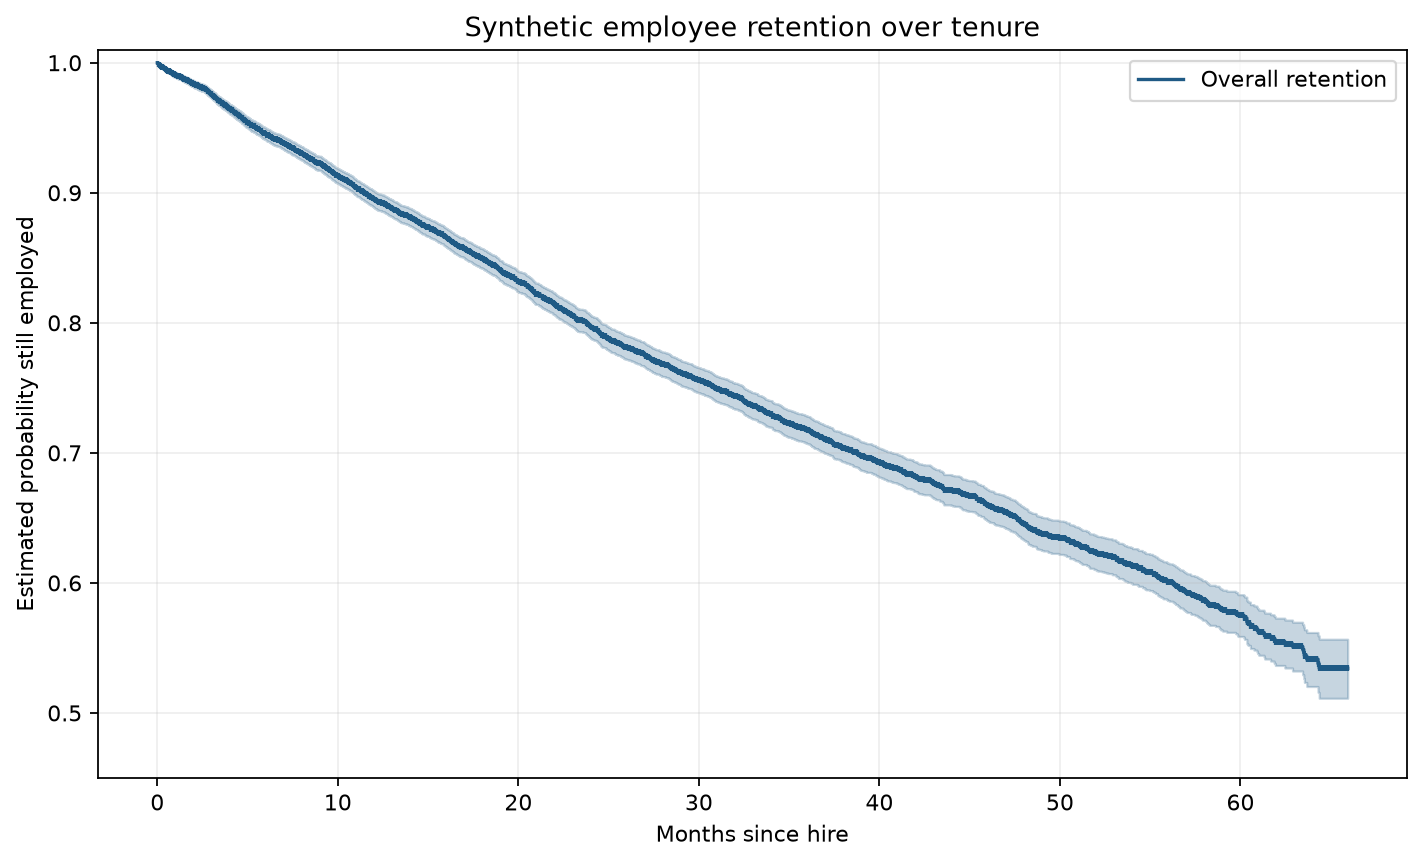

In [3]:
from IPython.display import Image, display
display(Image(filename=output_dir / "figures" / "overall_survival_curve.png"))

At 12 months, estimated retention is 89.53%. At 60 months, it is
57.51%. These are synthetic cohort estimates, not forecasts for another
organization.

## 3. Descriptive subgroup curves

Groups use values reconstructed at hire. Omnibus log-rank tests describe
whether complete curves differ; they do not establish that a group label
causes attrition.

In [4]:
groups = pd.read_csv(output_dir / "survival_group_summary.csv")
groups.loc[
    groups["group_feature"].eq("employment_type"),
    [
        "group",
        "employees",
        "observed_exits",
        "right_censored",
        "retention_12m",
        "retention_36m",
        "retention_60m",
    ],
]

group,employees,observed_exits,right_censored,retention_12m,retention_36m,retention_60m
Hourly,1813,565,1248,86.70%,64.84%,48.88%
Salaried,8083,2026,6057,90.17%,73.28%,59.29%


In [5]:
logrank = pd.read_csv(output_dir / "survival_logrank_tests.csv")
logrank

group_feature,groups,test_statistic,p_value,descriptive_difference_detected,causal_interpretation_permitted
employment_type,2,52.122056,5.215580e-13,True,False
hire_department_name,8,36.671336,5.413164e-06,True,False
hire_job_level,4,61.028488,3.543951e-13,True,False
hire_region,4,33.257257,2.842344e-07,True,False


## 4. Adjusted baseline-at-hire hazard associations

The penalized Cox model uses age, salary position, employment type,
education, department, and job level as known at hire. A hazard ratio above
1 means higher modeled instantaneous exit hazard; below 1 means lower hazard.
Confidence intervals crossing 1 indicate substantial uncertainty.

In [6]:
hazards = pd.read_csv(output_dir / "cox_hazard_ratios.csv")
hazards[[
    "interpretation",
    "hazard_ratio",
    "hazard_ratio_lower_95",
    "hazard_ratio_upper_95",
    "p_value",
]].head(10)

interpretation,hazard_ratio,hazard_ratio_lower_95,hazard_ratio_upper_95,p_value
4 compared with 1,1.1944,0.9041,1.5780,0.2111
Salary Position At Hire (per 1 SD increase),0.8382,0.8044,0.8733,0.0000
Doctorate compared with Associate,0.8652,0.6808,1.0995,0.2363
Salaried compared with Hourly,0.8679,0.7570,0.9950,0.0422
Supply Chain compared with Customer Support,0.8834,0.7689,1.0150,0.0801
Engineering compared with Customer Support,0.9023,0.8008,1.0166,0.0913
Sales compared with Customer Support,0.9115,0.7884,1.0539,0.2110
3 compared with 1,0.9329,0.8242,1.0559,0.2716
Finance compared with Customer Support,1.0704,0.9166,1.2501,0.3898
Human Resources compared with Customer Support,1.0528,0.8951,1.2384,0.5341


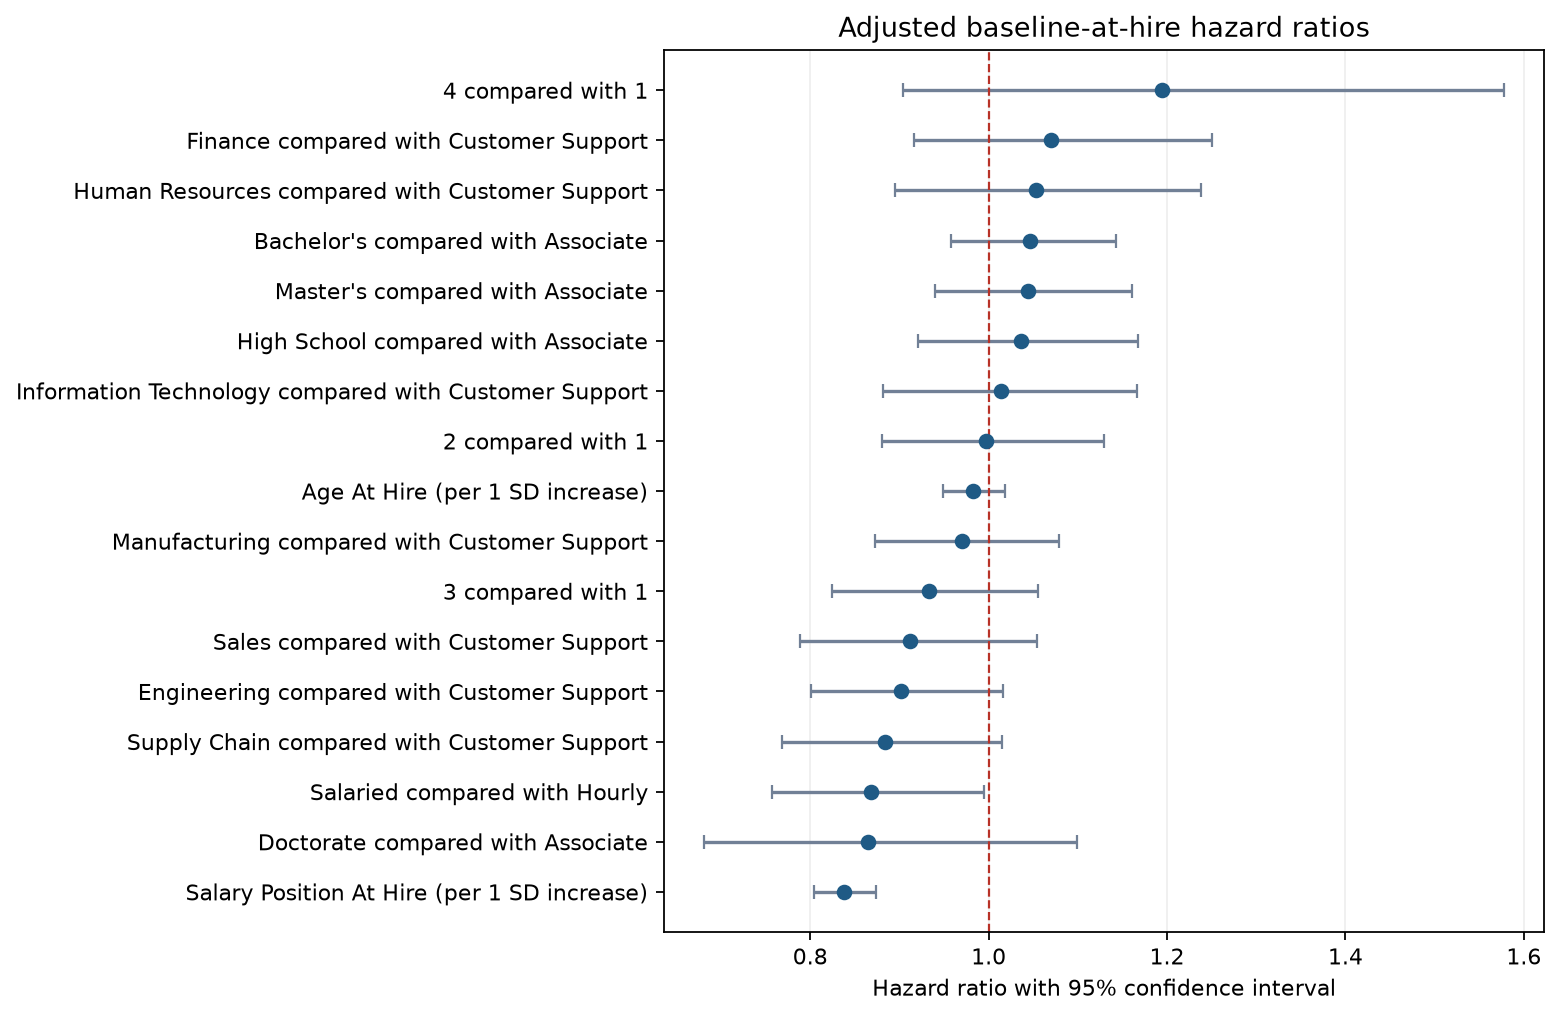

In [7]:
display(Image(filename=output_dir / "figures" / "cox_hazard_ratios.png"))

Hazard ratios are adjusted synthetic associations, not causal
effects. Later promotions, transfers, reviews, training, compensation
changes, current scores, and intervention selections are excluded.

## 5. Held-out concordance and model-assumption checks

Five folds measure ordering on employees excluded from each fold's fit.
Concordance of 0.5 is random ordering and 1.0 is perfect ordering.

In [8]:
cross_validation = pd.read_csv(output_dir / "cox_cross_validation.csv")
cross_validation[[
    "fold",
    "fit_rows",
    "validation_rows",
    "validation_events",
    "row_overlap",
    "concordance_index",
]]

fold,fit_rows,validation_rows,validation_events,row_overlap,concordance_index
1,7916,1980,519,0,0.5809
2,7917,1979,518,0,0.5719
3,7917,1979,518,0,0.5660
4,7917,1979,518,0,0.5707
5,7917,1979,518,0,0.5795


In [9]:
ph_tests = pd.read_csv(
    output_dir / "cox_proportional_hazards_test.csv"
)
ph_tests[[
    "encoded_feature",
    "test_statistic",
    "p",
    "proportional_hazards_review_flag",
]].head(8)

encoded_feature,test_statistic,p,proportional_hazards_review_flag
salary_position_at_hire_z,7.9583,0.0048,True
hire_department_name_Sales,0.9958,0.3183,False
hire_department_name_Supply_Chain,0.5645,0.4524,False
hire_department_name_Human_Resources,0.5633,0.4529,False
hire_job_level_4,0.5199,0.4709,False
education_level_Doctorate,0.4242,0.5149,False
hire_department_name_Engineering,0.4049,0.5246,False
education_level_Bachelor_s,0.4008,0.5267,False


Mean held-out concordance is 0.5738, a modest signal. Salary
position at hire triggers the precommitted proportional-hazards review flag.
Its single hazard ratio should therefore be read as an average association
over tenure rather than a constant effect.

## 6. Validation and governance

In [10]:
validation = pd.read_csv(output_dir / "survival_validation.csv")
print(
    f"Checks passed: {validation['status'].eq('PASS').sum()}/"
    f"{len(validation)}"
)
validation[["check", "status"]]

Checks passed: 25/25


## 7. Interpretation limits

- Active employees are right-censored, not assumed never to leave.
- Censoring is assumed noninformative.
- Baseline covariates do not represent later time-varying changes.
- Log-rank differences and Cox hazard ratios are not causal effects.
- One proportional-hazards diagnostic is explicitly flagged.
- This cross-validation is not the primary classifier's temporal test.
- No employee-level survival row or prediction is saved.
- Human review remains required, and automatic employment action is
  prohibited.